In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/housing_cleaned.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Dont need target and features for feature selection
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 9)
Target shape: (20640,)


In [3]:
# Split ocean_proximity (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

print("New feature shape:", X.shape)
X.head()

New feature shape: (20640, 12)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122,37,41,880,129,322,126,8,0,0,1,0
1,-122,37,21,7099,1106,2401,1138,8,0,0,1,0
2,-122,37,52,1467,190,496,177,7,0,0,1,0
3,-122,37,52,1274,235,558,219,5,0,0,1,0
4,-122,37,52,1627,280,565,259,3,0,0,1,0


In [4]:
# Compute correlation with target
corr_with_target = X.corrwith(y)

# Sort from strongest to weakest
corr_with_target = corr_with_target.sort_values(ascending=False)

corr_with_target

median_income                 0.678402
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.041666
latitude                     -0.134373
ocean_proximity_INLAND       -0.484859
dtype: float64

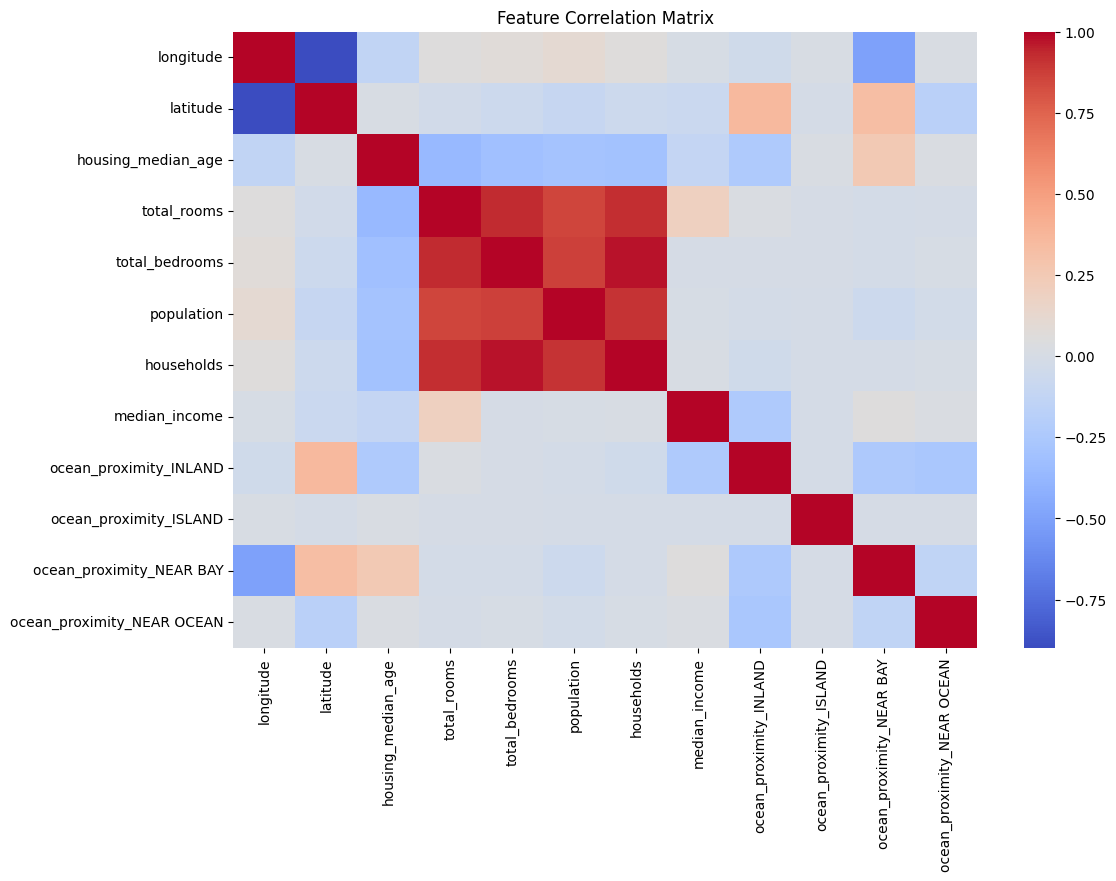

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [6]:
import numpy as np

corr_matrix = X.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with the highest correlation
high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

high_corr

['latitude', 'total_bedrooms', 'population', 'households']

In [7]:
# New ratio features
X["rooms_per_household"] = X["total_rooms"]/X["households"]
X["bedrooms_per_room"] = X["total_bedrooms"]/X["total_rooms"]
X["population_per_household"] = X["population"]/X["households"]

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122,37,41,880,129,322,126,8,0,0,1,0,6.984127,0.146591,2.555556
1,-122,37,21,7099,1106,2401,1138,8,0,0,1,0,6.238137,0.155797,2.109842
2,-122,37,52,1467,190,496,177,7,0,0,1,0,8.288136,0.129516,2.802260
3,-122,37,52,1274,235,558,219,5,0,0,1,0,5.817352,0.184458,2.547945
4,-122,37,52,1627,280,565,259,3,0,0,1,0,6.281853,0.172096,2.181467


In [8]:
# Recompute correlation using new ratio features
corr_with_target = X.corrwith(y).sort_values(ascending=False)

corr_with_target

median_income                 0.678402
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population_per_household     -0.023737
population                   -0.024650
longitude                    -0.041666
latitude                     -0.134373
bedrooms_per_room            -0.233303
ocean_proximity_INLAND       -0.484859
dtype: float64

In [10]:
# Drop columns with low correlation
X = X.drop(columns=[
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "ocean_proximity_ISLAND",
    "population_per_household",
    "longitude"
])

X.head()

,latitude,housing_median_age,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room
0,37,41,8,0,1,0,6.984127,0.146591
1,37,21,8,0,1,0,6.238137,0.155797
2,37,52,7,0,1,0,8.288136,0.129516
3,37,52,5,0,1,0,5.817352,0.184458
4,37,52,3,0,1,0,6.281853,0.172096


In [ ]:
# Check correlations
corr_with_target = X.corrwith(y).sort_values(ascending=False)
corr_with_target

median_income                 0.678402
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
housing_median_age            0.105623
latitude                     -0.134373
bedrooms_per_room            -0.233303
ocean_proximity_INLAND       -0.484859
dtype: float64

In [ ]:
# Standardize Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Fit Lasso
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01) #testing small alpha

lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
lasso_coefs.sort_values(ascending=False)


median_income                 76135.769129
housing_median_age            11267.400939
bedrooms_per_room             10704.565543
ocean_proximity_NEAR OCEAN     5975.560578
rooms_per_household            3757.433776
ocean_proximity_NEAR BAY       3305.367671
latitude                       3014.154248
ocean_proximity_INLAND       -33701.751889
dtype: float64

In [16]:
# Combine selected features with target feature
final_df = pd.concat([X, y], axis=1)

# Save feature selection dataset
final_df.to_csv("../data/processed/housing_feature_selected.csv", index=False)